IMport libraries

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LinearRegression,LogisticRegression

In [69]:
df = pd.read_csv("Dataset_Study3.csv")
df.head(10)

,HRV_MeanNN,HRV_SDNN,HRV_RMSSD,HRV_Prc20NN,HRV_Prc80NN,HRV_pNN50,HRV_HTI,HRV_VLF,HRV_LF,HRV_HF,HRV_TP,HRV_LFHF,HRV_SD1,HRV_SD2,HRV_SD1SD2,HRV_DFA_alpha1,HRV_DFA_alpha2,HRV_ApEn,HRV_SampEn,Label
0,838.708920,77.858966,42.966689,773.2,907.4,21.962617,15.285714,135.219052,1984.443232,941.576892,3083.350848,2.107574,30.452465,105.943750,0.287440,1.482091,0.754264,0.863522,1.311373,-1
1,899.929293,80.454862,50.910712,838.6,960.4,24.623116,15.307692,77.009053,1012.790954,712.205460,1835.167749,1.422049,36.089337,108.046467,0.334017,1.443776,0.683996,0.920773,1.357924,310
2,827.319444,64.428505,40.450375,766.4,881.8,20.276498,15.500000,129.751167,1924.529470,761.893623,2848.723565,2.525982,28.668833,86.661784,0.330813,1.335662,0.940213,0.974523,1.587459,109
3,768.630901,76.803474,43.512943,699.0,837.4,23.076923,16.714286,163.822696,4643.049228,806.486463,5625.889299,5.757132,30.832839,104.157364,0.296022,1.542718,0.598340,0.831501,1.081248,-1
4,807.432432,82.942629,49.326201,731.0,879.2,18.834081,13.937500,132.967712,2348.301339,567.338064,3066.742236,4.139157,34.955488,111.937167,0.312278,1.467014,0.611829,0.821712,1.107051,310
5,804.117117,74.328615,42.547246,734.0,879.8,22.869955,22.300000,56.847634,3055.110851,788.128565,3919.740426,3.876412,30.153151,100.908805,0.298816,1.433466,0.480802,0.896420,1.272410,109
6,665.716418,42.591624,20.633975,626.2,701.4,1.486989,11.208333,9.397069,927.370037,106.138115,1046.596267,8.737389,14.617538,58.524533,0.249768,1.640518,0.586531,0.994589,1.248209,-1
7,669.413534,48.501706,22.300200,634.2,705.6,2.247191,8.900000,156.837686,1049.075697,201.527680,1415.521787,5.205616,15.798299,66.874456,0.236238,1.594620,0.881005,0.842260,1.029476,310
8,652.260073,46.384069,20.430702,614.6,683.8,2.919708,10.960000,118.930053,1029.116888,242.298556,1399.181320,4.247309,14.473007,64.077583,0.225867,1.580516,0.988102,0.959389,1.076803,109
9,693.600775,34.117210,19.094770,672.0,711.0,2.316602,5.886364,36.316294,581.083725,158.705220,781.097771,3.661403,13.528090,46.382053,0.291666,1.587652,0.818773,0.879334,1.099340,-1


In [48]:
df.shape

(426, 20)

In [49]:
df.columns

Index(['HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD', 'HRV_Prc20NN', 'HRV_Prc80NN',
       'HRV_pNN50', 'HRV_HTI', 'HRV_VLF', 'HRV_LF', 'HRV_HF', 'HRV_TP',
       'HRV_LFHF', 'HRV_SD1', 'HRV_SD2', 'HRV_SD1SD2', 'HRV_DFA_alpha1',
       'HRV_DFA_alpha2', 'HRV_ApEn', 'HRV_SampEn', 'Label'],
      dtype='object')

In [70]:
y = df['Label']

In [71]:
df.drop('Label',axis =1,inplace =True)

In [72]:
y

0       -1
1      310
2      109
3       -1
4      310
      ... 
421    310
422    109
423     -1
424    310
425    109
Name: Label, Length: 426, dtype: int64

In [54]:
len(df)

8520

In [56]:
df = df.values.reshape(-1,1)

In [51]:
df.shape

(8520, 1)

In [52]:
print(df)

[[8.38708920e+02]
 [7.78589658e+01]
 [4.29666886e+01]
 ...
 [8.26008569e-01]
 [8.55325585e-01]
 [1.09000000e+02]]


#increased accuracy

In [88]:
from sklearn.preprocessing import MinMaxScaler

In [89]:
min_max = MinMaxScaler()

In [90]:
min_max.fit(df)

MinMaxScaler()

In [91]:
min_max.transform(df)

array([[0.51449112, 0.1646246 , 0.09862618, ..., 0.37310911, 0.67136837,
        0.63542989],
       [0.62574608, 0.17159005, 0.1197139 , ..., 0.31679596, 0.7367439 ,
        0.66097333],
       [0.49379319, 0.12858726, 0.09194653, ..., 0.52213045, 0.79812274,
        0.78692612],
       ...,
       [0.22544276, 0.10043437, 0.05714658, ..., 0.51724874, 0.72552394,
        0.51103606],
       [0.13614478, 0.15995843, 0.0691826 , ..., 0.69409619, 0.47535203,
        0.28320778],
       [0.18337201, 0.09222459, 0.05579897, ..., 0.63352689, 0.62853133,
        0.38518299]])

#reduced accuracy

In [ ]:
from sklearn.preprocessing  import StandardScaler

In [102]:
std_scaler = StandardScaler()

In [103]:
std_scaler.fit(df)

StandardScaler()

In [104]:
std_scaler.transform(df)

array([[ 0.82969956,  0.54153598,  0.15088364, ..., -0.63882352,
        -0.78649786, -0.0122543 ],
       [ 1.48142225,  0.62483285,  0.40637943, ..., -0.9723079 ,
        -0.19627918,  0.15133108],
       [ 0.70845268,  0.11058071,  0.06995393, ...,  0.24367527,
         0.35785691,  0.95795809],
       ...,
       [-0.86352281, -0.2260878 , -0.35167723, ...,  0.21476597,
        -0.29757434, -0.80889738],
       [-1.38662333,  0.48573524, -0.20585053, ...,  1.26204996,
        -2.55615845, -2.26795557],
       [-1.10996996, -0.32426509, -0.36800466, ...,  0.90336086,
        -1.17323608, -1.61488574]])

In [105]:
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2)


In [106]:
logistic = LogisticRegression()

In [107]:
logistic.fit(X_train,y_train)

C:\Users\Aditi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [108]:
logistic.predict(X_test)

array([109, 310, 310, 310, 109, 310, 310,  -1, 310,  -1, 109,  -1, 310,
       310, 310,  -1,  -1,  -1,  -1, 109, 109, 310, 109, 109,  -1, 109,
        -1,  -1,  -1,  -1,  -1, 310, 310, 310, 310, 310, 310,  -1, 109,
       310, 310,  -1,  -1, 310, 310, 109, 310, 109, 310, 310, 310, 109,
       109,  -1, 310, 109, 310, 109,  -1, 310, 310, 109,  -1, 109,  -1,
       310, 310,  -1, 310,  -1, 109, 109, 109, 109,  -1,  -1, 109, 109,
       310, 109, 109, 109, 109, 109, 310, 109], dtype=int64)

In [109]:
logistic.score(X_test,y_test)

0.27906976744186046

decision tree


In [97]:
from sklearn import tree


In [110]:
dtree = tree.DecisionTreeClassifier()

In [111]:
dtree.fit(X_train,y_train)

DecisionTreeClassifier()

In [112]:
dtree.predict(X_test)

array([ -1, 310, 310, 310, 109, 310, 310,  -1, 109, 310,  -1,  -1, 109,
       310,  -1, 109, 109,  -1,  -1, 109, 310,  -1,  -1, 109, 109, 310,
       310,  -1, 310,  -1, 310,  -1, 109, 310, 109, 109,  -1, 109,  -1,
        -1, 109, 109, 310, 109,  -1,  -1, 310, 109, 310,  -1, 109,  -1,
       109, 109, 310, 109, 109, 109,  -1, 109, 109,  -1, 310, 109,  -1,
       109, 310,  -1, 310, 310,  -1, 109, 310, 310, 310,  -1, 310, 310,
        -1, 109,  -1, 109, 310, 310,  -1, 310], dtype=int64)

In [113]:
dtree.score(X_test,y_test)

0.3023255813953488

SVm

In [114]:
from sklearn.svm import SVC

In [115]:
svc = SVC()

In [118]:
svc.fit(X_train,y_train)

SVC()

In [119]:
svc.predict(X_test)

array([109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109,
       109, 109, 109, 109, 109,  -1, 109, 109, 109, 109, 109,  -1, 109,
       109, 109, 109,  -1, 109, 109, 109, 109, 109, 109, 109, 109, 109,
       109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109,
       109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109, 109,  -1,
       109, 109,  -1, 109, 109, 109, 109, 109, 109, 109,  -1, 109, 109,
       109, 109, 109, 109, 109, 109, 109, 109], dtype=int64)

In [120]:
svc.score(X_test,y_test)

0.29069767441860467

random forest

In [121]:
from sklearn.ensemble import RandomForestClassifier

In [122]:
rf = RandomForestClassifier()

In [123]:
rf.fit(X_train,y_train)

RandomForestClassifier()

In [124]:
rf.predict(X_test)

array([109,  -1, 310,  -1, 109,  -1, 310, 109,  -1,  -1, 310, 109, 109,
       109, 310,  -1, 109,  -1,  -1, 109, 310,  -1, 109, 109,  -1, 310,
       310, 310, 109,  -1, 109, 310,  -1, 109, 310, 310, 310, 109, 109,
       310, 310,  -1,  -1, 109,  -1, 109, 310, 109, 109,  -1, 109, 310,
       109, 109, 310, 109, 109,  -1,  -1, 109, 109, 109, 109, 109,  -1,
       109, 310,  -1, 310,  -1, 109, 109,  -1, 109,  -1,  -1, 109, 109,
        -1,  -1, 310, 109, 310,  -1, 310,  -1], dtype=int64)

In [125]:
rf.score(X_test,y_test)

0.16279069767441862

In [126]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [129]:
y_predict = rf.predict(X_test)

In [138]:
cm = confusion_matrix(y_predict,y_test)

In [139]:
print(cm)

[[ 4 10 14]
 [16  7 13]
 [ 9 10  3]]


In [133]:
import seaborn as sns
import matplotlib.pyplot as plt

rf confusion matrix

C:\Users\Aditi\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\matplotlib\text.py:1279: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if s != self._text:


Text(69.0, 0.5, 'truth')

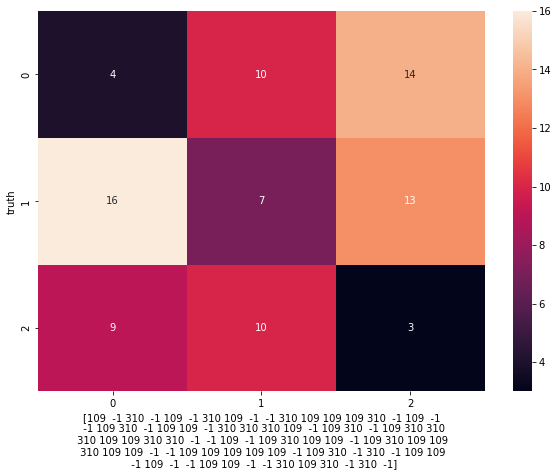

In [140]:
plt.figure(figsize=(10,7))
sns.heatmap(cm,annot=True)
plt.xlabel(y_predict)
plt.ylabel("truth")


confusion matrix tells the number of accuracy the model classifies

<Axes: >

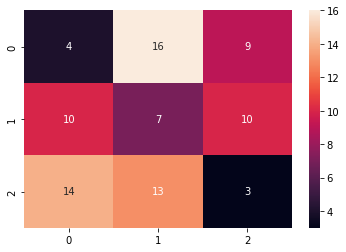

knn
cross validation 
gradient descent
